# CS3807 - Experiment 1: Single Layer Perceptron for Binary Classification

## Task 1: Dataset Loading and Exploration

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Global plotting style: bold x/y axis labels (applies to every plot below)
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

cols = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv('data_banknote_authentication.txt', header=None, names=cols)  # update path if needed

print(df.head())
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print(df.describe())

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
Shape: (1372, 5)
Missing values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.95

## Task 2: Exploratory Data Analysis (EDA)

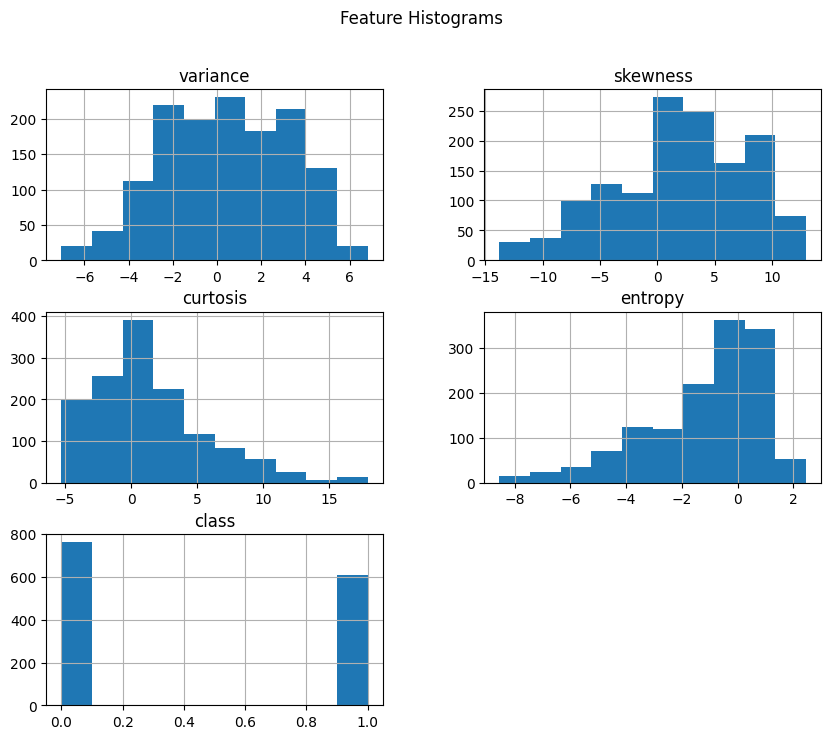

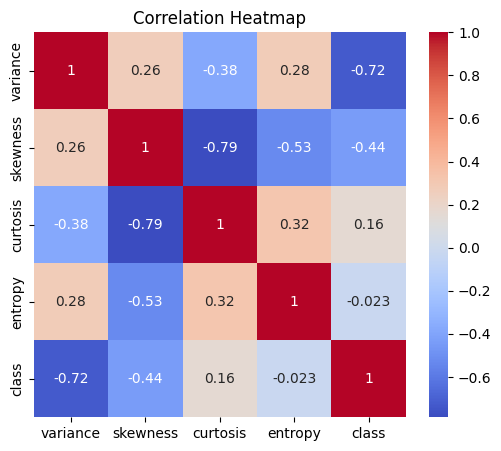

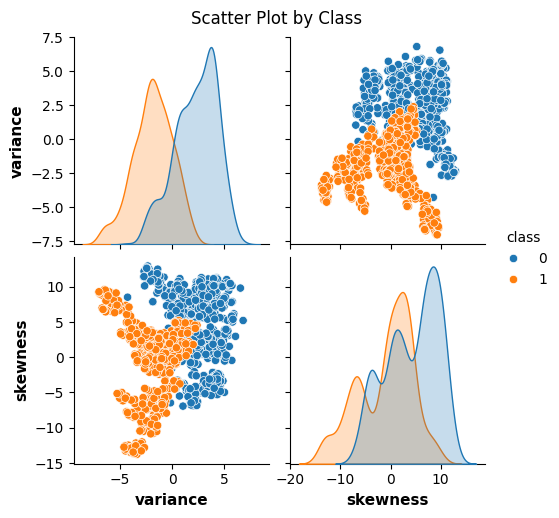

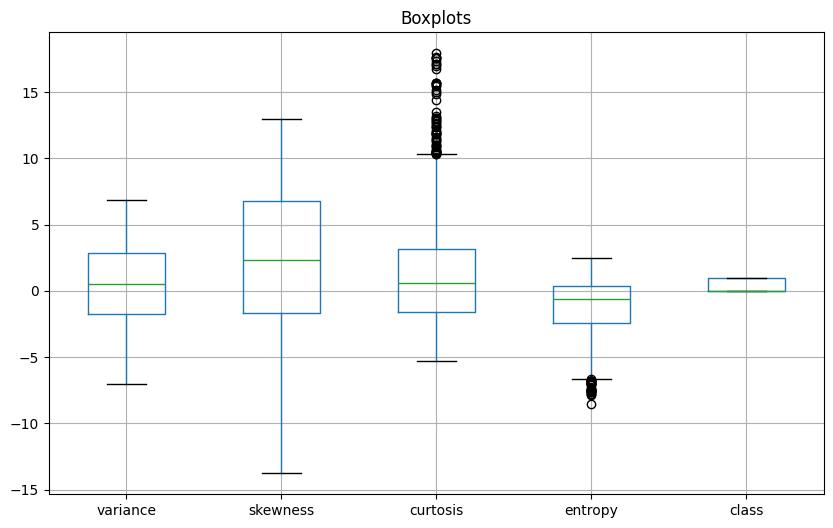

In [14]:
# Feature Histograms
fig = df.hist(figsize=(10,8))
plt.suptitle("Feature Histograms")
plt.savefig('histograms.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Scatter Plot by Class (pairplot returns a PairGrid, not a plt figure -- save via .savefig on the grid object)
g = sns.pairplot(df, hue='class', vars=['variance','skewness'])
g.fig.suptitle("Scatter Plot by Class", y=1.02)
g.savefig('scatter_plot.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Boxplots
plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Boxplots")
plt.savefig('boxplots.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

## Task 3: Data Preprocessing
Standardize features and create an 80/20 stratified train-test split.

In [15]:
X = df[['variance','skewness','curtosis','entropy']].values
y = df['class'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=109, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1097, 4) Test: (275, 4)


## Task 4: Perceptron Implementation (From Scratch)

In [16]:
class Perceptron:
    def __init__(self, n_features, lr=0.01, epochs=50):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        return self.activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(self.epochs):
            misclassified = 0
            for xi, yi in zip(X, y):
                z = np.dot(xi, self.w) + self.b
                y_hat = self.activation(z)
                update = self.lr * (yi - y_hat)
                if update != 0:
                    self.w += update * xi
                    self.b += update
                    misclassified += 1
            self.error_history.append(misclassified)
            self.weight_history.append(self.w.copy())
            self.bias_history.append(self.b)
            if verbose:
                print(f"Epoch {epoch+1:2d} | Misclassified: {misclassified:3d} | "
                      f"Weights: {np.round(self.w,3)} | Bias: {self.b:.3f}")
        return self

## Task 5: Model Training

In [17]:
model = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50)
model.fit(X_train, y_train)

Epoch  1 | Misclassified:  50 | Weights: [-0.067 -0.071 -0.057  0.022] | Bias: -0.040
Epoch  2 | Misclassified:  28 | Weights: [-0.083 -0.089 -0.093  0.004] | Bias: -0.040
Epoch  3 | Misclassified:  20 | Weights: [-0.105 -0.111 -0.091 -0.005] | Bias: -0.040
Epoch  4 | Misclassified:  15 | Weights: [-0.097 -0.116 -0.101  0.018] | Bias: -0.050
Epoch  5 | Misclassified:  19 | Weights: [-0.108 -0.121 -0.108 -0.001] | Bias: -0.040
Epoch  6 | Misclassified:  16 | Weights: [-0.109 -0.131 -0.103  0.022] | Bias: -0.060
Epoch  7 | Misclassified:  19 | Weights: [-0.107 -0.143 -0.118  0.008] | Bias: -0.050
Epoch  8 | Misclassified:  16 | Weights: [-0.123 -0.142 -0.121 -0.003] | Bias: -0.050
Epoch  9 | Misclassified:  18 | Weights: [-0.141 -0.139 -0.122 -0.017] | Bias: -0.050
Epoch 10 | Misclassified:  20 | Weights: [-0.123 -0.149 -0.144 -0.003] | Bias: -0.050
Epoch 11 | Misclassified:  18 | Weights: [-0.133 -0.153 -0.145 -0.002] | Bias: -0.050
Epoch 12 | Misclassified:  18 | Weights: [-0.14  -0.16

## Task 6: Model Evaluation
Accuracy, Precision, Recall, F1-score, Confusion Matrix, and the required parameter/error plots -- all saved as 600 dpi `.eps` files.

Accuracy: 0.9782
Precision: 0.9754
Recall: 0.9754
F1: 0.9754


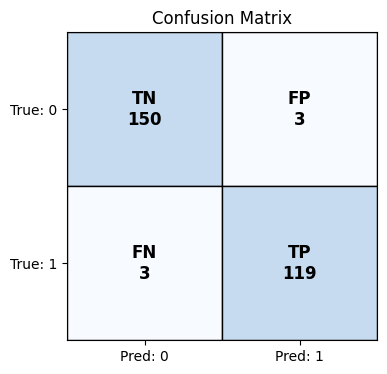

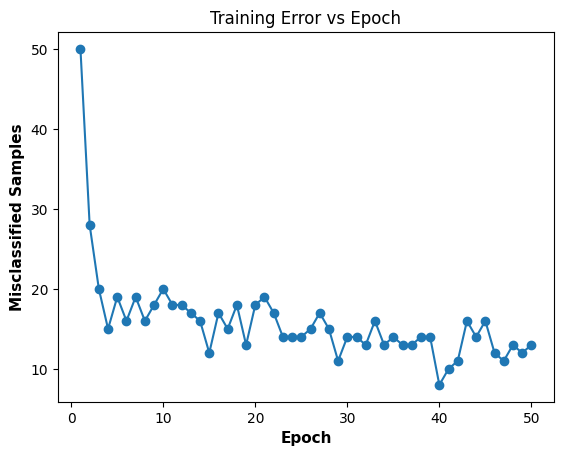

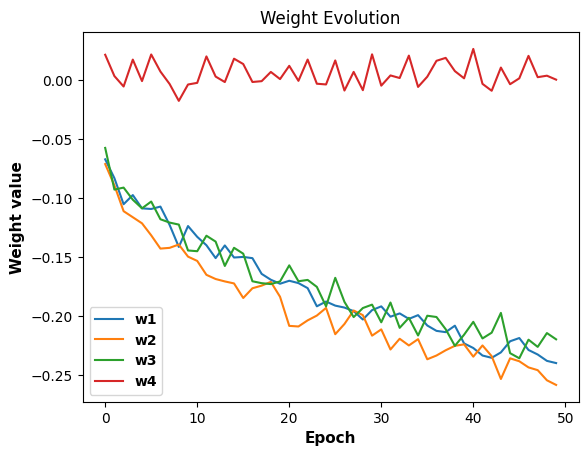

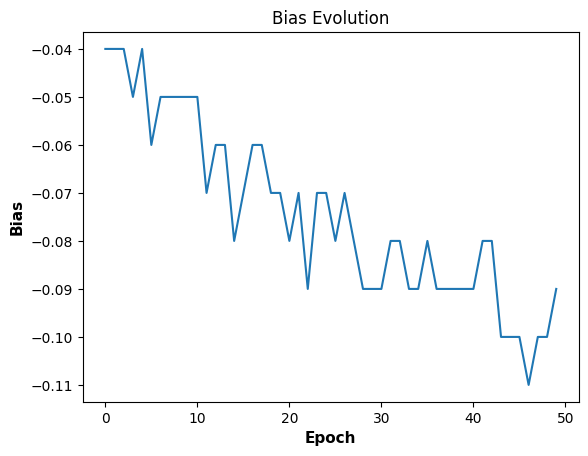

In [18]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(4,4))
labels = [['TN\n150','FP\n3'],['FN\n3','TP\n119']]
colors = [['#c6dbef','#f7fbff'],['#f7fbff','#c6dbef']]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j,1-i), 1, 1, facecolor=colors[i][j], edgecolor='black'))
        ax.text(j+0.5, 1.5-i, labels[i][j], ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0,2); ax.set_ylim(0,2); ax.set_xticks([0.5,1.5]); ax.set_yticks([0.5,1.5])
ax.set_xticklabels(['Pred: 0','Pred: 1']); ax.set_yticklabels(['True: 1','True: 0'])
ax.set_title("Confusion Matrix")
plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Training Error vs Epoch
plt.figure()
plt.plot(range(1, model.epochs+1), model.error_history, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Misclassified Samples"); plt.title("Training Error vs Epoch")
plt.savefig('training_error.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Weight Evolution
plt.figure()
wh = np.array(model.weight_history)
for i in range(wh.shape[1]):
    plt.plot(wh[:,i], label=f'w{i+1}')
plt.xlabel("Epoch"); plt.ylabel("Weight value"); plt.title("Weight Evolution"); plt.legend(prop={'weight':'bold'})
plt.savefig('weight_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Bias Evolution
plt.figure()
plt.plot(model.bias_history)
plt.xlabel("Epoch"); plt.ylabel("Bias"); plt.title("Bias Evolution")
plt.savefig('bias_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

## Additional Task: Learning Rate Comparison (Required)

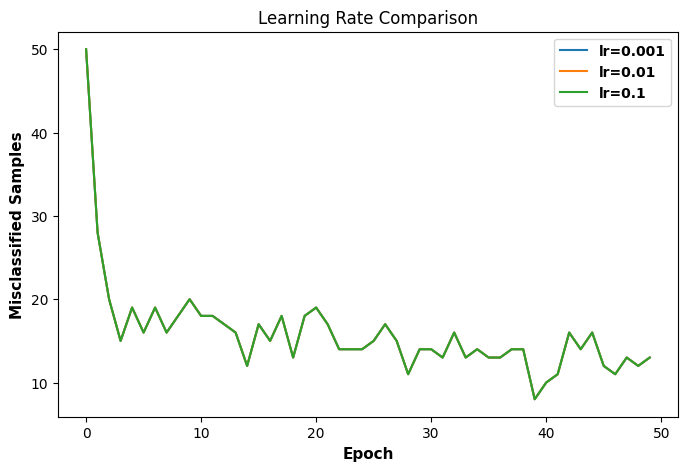

In [19]:
lrs = [0.001, 0.01, 0.1]
plt.figure(figsize=(8,5))
for lr in lrs:
    m = Perceptron(n_features=X_train.shape[1], lr=lr, epochs=50)
    m.fit(X_train, y_train, verbose=False)
    plt.plot(m.error_history, label=f'lr={lr}')
plt.xlabel("Epoch"); plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison"); plt.legend(prop={'weight':'bold'})
plt.savefig('lr_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

## Additional Task: Decision Boundary (Optional, 2 Features)

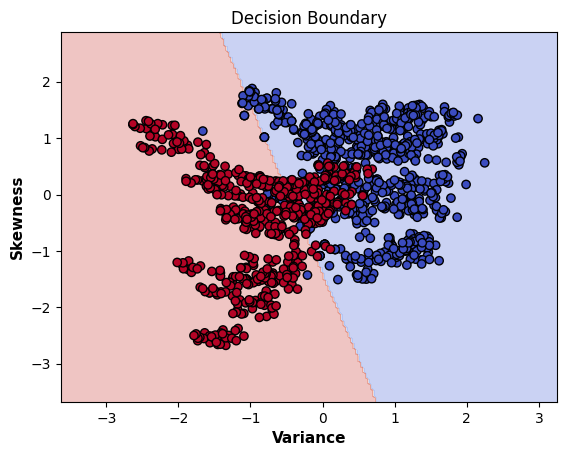

In [20]:
X2 = X_scaled[:, :2]  # variance, skewness only
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=109, stratify=y)
m2 = Perceptron(n_features=2, lr=0.01, epochs=50)
m2.fit(X2_train, y2_train, verbose=False)

x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min,x_max,200), np.linspace(y_min,y_max,200))
Z = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X2[:,0], X2[:,1], c=y, edgecolors='k', cmap='coolwarm')
plt.xlabel("Variance"); plt.ylabel("Skewness"); plt.title("Decision Boundary")
plt.savefig('decision_boundary.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

## Additional Task: Comparison with Scikit-learn's Perceptron (Optional)

In [21]:
from sklearn.linear_model import Perceptron as SklearnPerceptron
sk_model = SklearnPerceptron(max_iter=50, eta0=0.01, random_state=109)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
print("Sklearn Accuracy:", accuracy_score(y_test, sk_pred))
print("Your model Accuracy:", acc)

Sklearn Accuracy: 0.9781818181818182
Your model Accuracy: 0.9781818181818182


## Download all .eps files

In [22]:
import shutil
eps_files = ['histograms.eps','correlation_heatmap.eps','scatter_plot.eps','boxplots.eps',
             'training_error.eps','weight_evolution.eps','bias_evolution.eps',
             'confusion_matrix.eps','lr_comparison.eps','decision_boundary.eps']
import os
os.makedirs('eps_plots', exist_ok=True)
for f in eps_files:
    if os.path.exists(f):
        shutil.copy(f, f'eps_plots/{f}')
shutil.make_archive('plots', 'zip', 'eps_plots')
print("Saved plots.zip -- download it from the Colab Files sidebar.")

Saved plots.zip -- download it from the Colab Files sidebar.
